# TFT Training — Cádiz NWP Forecast Model

This notebook trains a TFT on the NWP-augmented dataset produced by `6_nwp_data_assembly.ipynb`
and preprocessed by `3b_nwp_preprocessing.ipynb`.

## Key difference from notebook 4 (standard model)
The 7 Open-Meteo ECMWF forecast columns are added to `time_varying_known_reals`, making them
**decoder-visible**. The TFT can now attend to tomorrow's predicted weather when generating
the 24h forecast. ERA5 observed weather stays in `time_varying_unknown_reals` (encoder-only).

| | Standard model (nb 4) | NWP model (this notebook) |
|---|---|---|
| `known_future` (decoder) | 9 features (calendar + geometry) | 16 features (+7 NWP forecast) |
| `observed` (encoder only) | 8 ERA5 features | 8 ERA5 features (unchanged) |

**Pipeline steps:**

| # | Step | Purpose |
|---|---|---|
| 0 | Imports & setup | Libraries, GPU detection, random seed |
| 1 | Configuration | Sequence lengths, feature lists, denorm params |
| 2 | Data loading | Load NWP CSVs, add time_idx and group_id |
| 3 | TimeSeriesDataSet construction | 16 known_future + 8 observed |
| 4 | Learning rate finder | Establish LR range before tuning |
| 5 | Hyperparameter tuning | Optuna TPE, 15 trials |
| 6 | Final model training | Best HPs, early stopping, checkpointing |
| 7 | Validation evaluation | Denormalized metrics |
| 8 | Save artifacts | Model, study, metrics |

## Step 0 — Imports & setup

In [1]:
import os, json, warnings, pickle
import numpy as np
import numpy._core.multiarray
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.tuner import Tuner

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE
from pytorch_forecasting.data.encoders import TorchNormalizer

import optuna
from optuna.samplers import TPESampler

import functools

if not getattr(torch, '_orig_load', None):
    torch._orig_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return torch._orig_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
pl.seed_everything(42)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\nicol\Documents\ML-solar-forecast\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


PyTorch 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Ti


## Step 1 — Configuration

In [2]:
# ── Paths ──
DATA_DIR  = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models', 'nwp_forecast')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Sequence lengths ──
MAX_ENCODER_LENGTH    = 168   # 7 days of hourly history
MAX_PREDICTION_LENGTH = 24    # 1-day-ahead forecast

# ── Feature classification (matches 3b_nwp_preprocessing.ipynb Step 8) ──
KNOWN_FUTURE = [
    # calendar + solar geometry (deterministic)
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
    # NWP forecast weather — decoder-visible (NEW vs standard model)
    'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast',
    'surface_pressure_hPa_forecast', 'total_precip_mm_forecast',
    'kt_forecast', 'dewpoint_depression_C_forecast',
]
OBSERVED = [
    # ERA5 observed weather — encoder-only (unchanged)
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
TARGET = 'pv_generation_mwh'

# ── Denormalization parameters ──
with open(os.path.join(DATA_DIR, 'nwp_preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

print(f"Encoder: {MAX_ENCODER_LENGTH}h ({MAX_ENCODER_LENGTH//24}d)")
print(f"Prediction: {MAX_PREDICTION_LENGTH}h")
print(f"Known future features: {len(KNOWN_FUTURE)} (9 calendar/geometry + 7 NWP forecast)")
print(f"Observed features: {len(OBSERVED)} (ERA5 only)")
print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")

Encoder: 168h (7d)
Prediction: 24h
Known future features: 16 (9 calendar/geometry + 7 NWP forecast)
Observed features: 8 (ERA5 only)
Target denorm: z * 301.4196 + 228.7084


## Step 2 — Load data & prepare for TimeSeriesDataSet

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'nwp_train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc')
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'nwp_val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc')

print(f"Train: {len(train_df):,} rows  {train_df.index[0]} -> {train_df.index[-1]}")
print(f"Val:   {len(val_df):,} rows   {val_df.index[0]} -> {val_df.index[-1]}")
print(f"Train columns ({train_df.shape[1]}): {list(train_df.columns)}")

assert train_df.isna().sum().sum() == 0, "NaN in training data"
assert val_df.isna().sum().sum() == 0, "NaN in validation data"

train_df = train_df.reset_index()
val_df   = val_df.reset_index()

train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))

train_df['group_id'] = '0'
val_df['group_id']   = '0'

assert train_df['time_idx'].iloc[-1] + 1 == val_df['time_idx'].iloc[0], \
    "time_idx not continuous across train/val boundary"

print(f"\ntime_idx range — train: [0, {train_df['time_idx'].max()}], "
      f"val: [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")

Train: 17,544 rows  2023-01-01 00:00:00 -> 2024-12-31 23:00:00
Val:   4,344 rows   2025-01-01 00:00:00 -> 2025-06-30 23:00:00
Train columns (25): ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast', 'surface_pressure_hPa_forecast', 'total_precip_mm_forecast', 'kt_forecast', 'dewpoint_depression_C_forecast', 'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa', 'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C', 'pv_generation_mwh']

time_idx range — train: [0, 17543], val: [17544, 21887]


## Step 3 — Construct TimeSeriesDataSet

In [4]:
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],

    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,

    time_varying_known_reals=KNOWN_FUTURE,
    time_varying_unknown_reals=OBSERVED,

    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE + OBSERVED},

    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

val_with_context = pd.concat([
    train_df.iloc[-MAX_ENCODER_LENGTH:],
    val_df
], ignore_index=True)

val_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    val_with_context,
    stop_randomization=True,
)

BATCH_SIZE = 64
train_dataloader = training_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=2)
val_dataloader   = val_dataset.to_dataloader(     train=False, batch_size=BATCH_SIZE, num_workers=2)

print(f"Training dataset: {len(training_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")

x, y = next(iter(train_dataloader))
print(f"\nBatch shapes:")
print(f"  Encoder cont. inputs: {x['encoder_cont'].shape}")
print(f"  Decoder cont. inputs: {x['decoder_cont'].shape}  ← includes {len(KNOWN_FUTURE)} known_future")
print(f"  Target:               {y[0].shape}")

Training dataset: 17353 samples
Validation dataset: 4321 samples

Batch shapes:
  Encoder cont. inputs: torch.Size([64, 168, 26])
  Decoder cont. inputs: torch.Size([64, 24, 26])  ← includes 16 known_future
  Target:               torch.Size([64, 24])


## Step 4 — Learning rate finder

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
Finding best initial lr: 

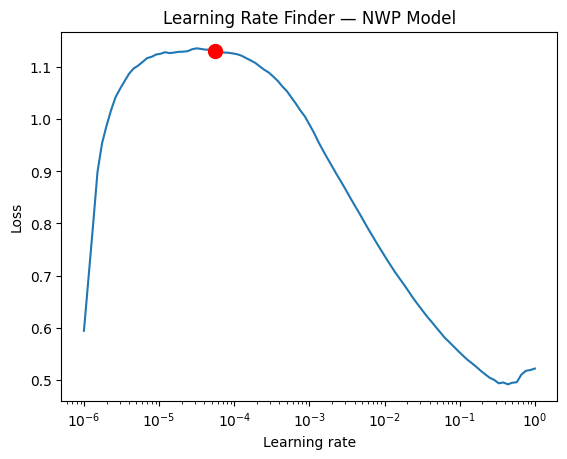

Suggested LR: 0.000055


In [5]:
tft_tmp = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
)

trainer_tmp = pl.Trainer(accelerator='auto', gradient_clip_val=0.1, max_epochs=3)
tuner = Tuner(trainer_tmp)
lr_finder = tuner.lr_find(
    tft_tmp,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    min_lr=1e-6, max_lr=1.0, num_training=100,
)

fig = lr_finder.plot(suggest=True)
plt.title("Learning Rate Finder — NWP Model")
plt.show()

suggested_lr = lr_finder.suggestion()
print(f"Suggested LR: {suggested_lr:.6f}")

del tft_tmp, trainer_tmp
torch.cuda.empty_cache()

## Step 5 — Hyperparameter tuning (Optuna, TPE, 15 trials)

In [6]:
def optuna_objective(trial):
    hidden_size            = trial.suggest_categorical('hidden_size', [16, 32, 64, 128])
    lstm_layers            = trial.suggest_int('lstm_layers', 1, 2)
    attention_head_size    = trial.suggest_categorical('attention_head_size', [1, 2, 4])
    dropout                = trial.suggest_float('dropout', 0.1, 0.4)
    hidden_continuous_size = trial.suggest_categorical('hidden_continuous_size', [8, 16, 32])
    learning_rate          = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    tft = TemporalFusionTransformer.from_dataset(
        training_dataset,
        hidden_size=hidden_size,
        lstm_layers=lstm_layers,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=hidden_continuous_size,
        learning_rate=learning_rate,
        loss=QuantileLoss(),
        optimizer='adam',
        reduce_on_plateau_patience=3,
        output_size=7,
    )

    trainer = pl.Trainer(
        max_epochs=10,
        accelerator='auto',
        gradient_clip_val=0.1,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, mode='min', verbose=False)],
        enable_model_summary=False,
        enable_progress_bar=False,
        enable_checkpointing=False,
        logger=False,
    )

    try:
        trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
        val_loss = trainer.callback_metrics['val_loss'].item()
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        val_loss = float('inf')
    finally:
        torch.cuda.empty_cache()

    return val_loss

In [7]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    study_name='tft_cadiz_nwp_hp_tuning',
)

study.optimize(optuna_objective, n_trials=15, show_progress_bar=True, gc_after_trial=True)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best val_loss: {study.best_value:.6f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-26 22:03:37,597] A new study created in memory with name: tft_cadiz_nwp_hp_tuning
  0%|          | 0/15 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  0%|          | 0/15 [05:10<?, ?it/s]

[I 2026-03-26 22:08:48,120] Trial 0 finished with value: 0.296690434217453 and parameters: {'hidden_size': 32, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.2803345035229627, 'hidden_continuous_size': 32, 'learning_rate': 0.004622589001020831}. Best is trial 0 with value: 0.296690434217453.


Best trial: 0. Best value: 0.29669:   7%|▋         | 1/15 [05:10<1:12:30, 310.75s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Best trial: 0. Best value: 0.29669:   7%|▋         | 1/15 [18:38<1:12:30, 310.75s/it]

[I 2026-03-26 22:22:15,805] Trial 1 finished with value: 0.2952767312526703 and parameters: {'hidden_size': 128, 'lstm_layers': 2, 'attention_head_size': 4, 'dropout': 0.14184815819561256, 'hidden_continuous_size': 32, 'learning_rate': 0.0037183641805732083}. Best is trial 1 with value: 0.2952767312526703.


Best trial: 1. Best value: 0.295277:  13%|█▎        | 2/15 [18:38<2:10:40, 603.08s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Best trial: 1. Best value: 0.295277:  13%|█▎        | 2/15 [25:40<2:10:40, 603.08s/it]

...

[I 2026-03-26 23:47:41,320] Trial 13 finished with value: 0.2976135313510895 and parameters: {'hidden_size': 64, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.3425793410379432, 'hidden_continuous_size': 8, 'learning_rate': 0.00028096735647379755}. Best is trial 10 with value: 0.24434080719947815.


Best trial: 10. Best value: 0.244341:  93%|█████████▎| 14/15 [1:44:03<07:18, 438.73s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Best trial: 10. Best value: 0.244341:  93%|█████████▎| 14/15 [1:51:05<07:18, 438.73s/it]

[I 2026-03-26 23:54:43,006] Trial 14 finished with value: 0.32599323987960815 and parameters: {'hidden_size': 64, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.19903880577839794, 'hidden_continuous_size': 16, 'learning_rate': 0.00016784361722487395}. Best is trial 10 with value: 0.24434080719947815.


Best trial: 10. Best value: 0.244341: 100%|██████████| 15/15 [1:51:05<00:00, 444.38s/it]


Best trial: #10
Best val_loss: 0.244341
Best params:
  hidden_size: 64
  lstm_layers: 1
  attention_head_size: 4
  dropout: 0.31222605509347556
  hidden_continuous_size: 8
  learning_rate: 0.00011952270129143879


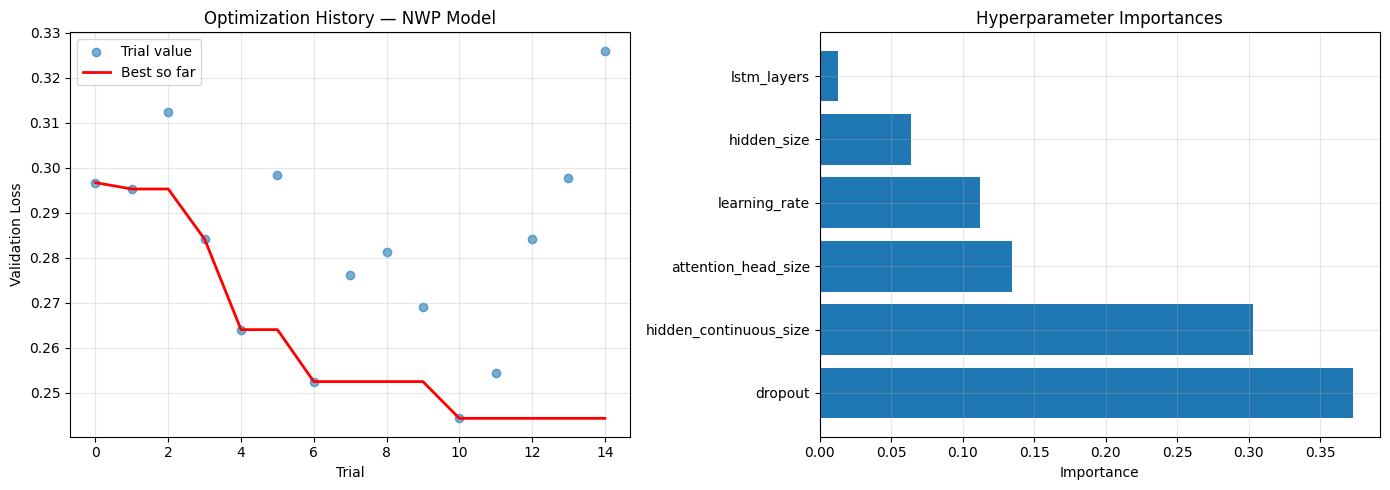

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trial_numbers = [t.number for t in study.trials if t.value is not None and t.value < float('inf')]
trial_values  = [t.value  for t in study.trials if t.value is not None and t.value < float('inf')]
best_so_far   = np.minimum.accumulate(trial_values)

axes[0].scatter(trial_numbers, trial_values, alpha=0.6, label='Trial value')
axes[0].plot(trial_numbers, best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Optimization History — NWP Model')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importances')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Train final model with best HPs

In [9]:
best = study.best_params

tft_final = TemporalFusionTransformer.from_dataset(
    training_dataset,
    hidden_size=best['hidden_size'],
    lstm_layers=best['lstm_layers'],
    attention_head_size=best['attention_head_size'],
    dropout=best['dropout'],
    hidden_continuous_size=best['hidden_continuous_size'],
    learning_rate=best['learning_rate'],
    loss=QuantileLoss(),
    optimizer='adam',
    reduce_on_plateau_patience=5,
    output_size=7,
)

print(f"Model parameters: {sum(p.numel() for p in tft_final.parameters()):,}")
print(f"Best HPs: {best}")

Model parameters: 290,471
Best HPs: {'hidden_size': 64, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.31222605509347556, 'hidden_continuous_size': 8, 'learning_rate': 0.00011952270129143879}


In [10]:
checkpoint_callback = ModelCheckpoint(
    dirpath=MODEL_DIR,
    filename='tft_nwp_best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer_final = pl.Trainer(
    max_epochs=75,
    accelerator='auto',
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, mode='min', verbose=True),
        checkpoint_callback,
        LearningRateMonitor(logging_interval='epoch'),
    ],
    log_every_n_steps=50,
)

trainer_final.fit(tft_final, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

print(f"\nBest model saved to: {checkpoint_callback.best_model_path}")
print(f"Best val_loss: {checkpoint_callback.best_model_score:.6f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    416 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.6 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 49.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 32.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 290 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 290 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 775                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_loss improved. New best score: 0.222
Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.214
Monitored metric val_loss did not improve in the last 10 records. Best score: 0.214. Signaling Trainer to stop.



Best model saved to: C:\Users\nicol\Documents\ML-solar-forecast\cadiz\models\nwp_forecast\tft_nwp_best-v1.ckpt
Best val_loss: 0.214147


## Step 7 — Validation evaluation

In [11]:
def denormalize(z_values):
    return z_values * TARGET_STD + TARGET_MEAN

def compute_metrics(actual_mwh, predicted_mwh):
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    nrmse = (rmse / TARGET_MEAN) * 100  # normalized by train-set mean
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2), 'nRMSE_pct': float(nrmse)}

In [12]:
best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_callback.best_model_path)
best_model.eval()

val_predictions = best_model.predict(
    val_dataloader, mode='prediction', return_x=True, return_y=True,
)

pred_z   = val_predictions.output.cpu().numpy()
actual_z = val_predictions.y[0].cpu().numpy()

# Per-timestep aggregation: average overlapping 24h windows
n_val = len(val_df)
agg_sum = np.zeros(n_val)
agg_count = np.zeros(n_val)
n_windows = pred_z.shape[0]
for i in range(n_windows):
    for h in range(MAX_PREDICTION_LENGTH):
        t = i + h
        if t < n_val:
            agg_sum[t] += pred_z[i, h]
            agg_count[t] += 1
mask = agg_count > 0
pred_z_agg = np.zeros(n_val)
pred_z_agg[mask] = agg_sum[mask] / agg_count[mask]

pred_mwh   = np.clip(denormalize(pred_z_agg), 0, None)
actual_mwh = denormalize(val_df[TARGET].values)

val_metrics = compute_metrics(actual_mwh, pred_mwh)
print("Validation Metrics (original MWh scale):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nVal quantile loss (normalized): {checkpoint_callback.best_model_score:.6f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation Metrics (original MWh scale):
  MAE_MWh: 115.5133
  RMSE_MWh: 207.1267
  R2: 0.7284

Val quantile loss (normalized): 0.214147


## Step 8 — Save artifacts

In [13]:
with open(os.path.join(MODEL_DIR, 'nwp_hp_study.pkl'), 'wb') as f:
    pickle.dump(study, f)

hp_results = {
    'model': 'nwp',
    'best_trial': study.best_trial.number,
    'best_val_loss': study.best_value,
    'best_params': study.best_params,
    'n_trials': len(study.trials),
    'val_metrics_mwh': val_metrics,
    'feature_config': {
        'known_future': KNOWN_FUTURE,
        'observed': OBSERVED,
        'n_known_future': len(KNOWN_FUTURE),
        'n_observed': len(OBSERVED),
    },
    'sequence_config': {
        'max_encoder_length': MAX_ENCODER_LENGTH,
        'max_prediction_length': MAX_PREDICTION_LENGTH,
    },
}

with open(os.path.join(MODEL_DIR, 'nwp_hp_study_results.json'), 'w') as f:
    json.dump(hp_results, f, indent=2)

val_pred_df = pd.DataFrame({
    'actual_z': val_df[TARGET].values,
    'predicted_z': pred_z_agg,
    'actual_mwh': actual_mwh,
    'predicted_mwh': pred_mwh,
})
val_pred_df.to_csv(os.path.join(MODEL_DIR, 'nwp_val_predictions.csv'), index=False)

print("Artifacts saved:")
for f_name in sorted(os.listdir(MODEL_DIR)):
    f_path = os.path.join(MODEL_DIR, f_name)
    if os.path.isfile(f_path):
        print(f"  {f_name}: {os.path.getsize(f_path)/1e6:.1f} MB")

print("\nNext step: run 5c_nwp_evaluation.ipynb")

Artifacts saved:
  nwp_hp_study.pkl: 0.0 MB
  nwp_hp_study_results.json: 0.0 MB
  nwp_val_predictions.csv: 0.3 MB
  tft_nwp_best-v1.ckpt: 4.3 MB
  tft_nwp_best.ckpt: 4.0 MB

Next step: run 5c_nwp_evaluation.ipynb
